
# Introduction
<p align="center">
<img src="https://raw.githubusercontent.com/pbcquoc/vietocr/master/image/vietocr.jpg" width="512" height="512">
</p>
This notebook describe how you can use VietOcr to train OCR model




# Inference

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg

config = Cfg.load_config_from_name('vgg_transformer')

In [3]:
config = Cfg.load_config_from_name('vgg_transformer')

Change weights to your weights or using default weights from our pretrained model. Path can be url or local file

In [4]:
# config['weights'] = './weights/transformerocr.pth'
config['cnn']['pretrained']=False
config['device'] = 'cpu'

In [5]:
detector = Predictor(config)

e:\KL\env\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Model weight C:\Users\NHATVY~1\AppData\Local\Temp\vgg_transformer.pth exsits. Ignore download!


# Train model



1.   Load your config
2.   Train model using your dataset above



Load the default config, we adopt VGG for image feature extraction

In [6]:
from vietocr.tool.config import Cfg
from vietocr.model.trainer import Trainer

# Change the config

* *data_root*: the folder save your all images
* *train_annotation*: path to train annotation
* *valid_annotation*: path to valid annotation
* *print_every*: show train loss at every n steps
* *valid_every*: show validation loss at every n steps
* *iters*: number of iteration to train your model
* *export*: export weights to folder that you can use for inference
* *metrics*: number of sample in validation annotation you use for computing full_sequence_accuracy, for large dataset it will take too long, then you can reuduce this number


In [7]:
config = Cfg.load_config_from_name('vgg_transformer')

In [8]:

dataset_params = {
    'name':'hw',
    'data_root':'E:\KL\ocr_datasets',
    'train_annotation':'label_train_fixed.txt',
    'valid_annotation':'label_val_fixed.txt'
}

params = {
         'print_every':200,
         'valid_every':15*200,
          'iters':20000,
          'checkpoint':'./checkpoint/transformerocr_checkpoint.pth',    
          'export':'./weights/transformerocr.pth',
          'metrics': 10000
         }

config['trainer'].update(params)
config['dataset'].update(dataset_params)
config['device'] = 'cpu'

you can change any of these params in this full list below

In [9]:
config

{'vocab': 'aAàÀảẢãÃáÁạẠăĂằẰẳẲẵẴắẮặẶâÂầẦẩẨẫẪấẤậẬbBcCdDđĐeEèÈẻẺẽẼéÉẹẸêÊềỀểỂễỄếẾệỆfFgGhHiIìÌỉỈĩĨíÍịỊjJkKlLmMnNoOòÒỏỎõÕóÓọỌôÔồỒổỔỗỖốỐộỘơƠờỜởỞỡỠớỚợỢpPqQrRsStTuUùÙủỦũŨúÚụỤưƯừỪửỬữỮứỨựỰvVwWxXyYỳỲỷỶỹỸýÝỵỴzZ0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~ ',
 'device': 'cpu',
 'seq_modeling': 'transformer',
 'transformer': {'d_model': 256,
  'nhead': 8,
  'num_encoder_layers': 6,
  'num_decoder_layers': 6,
  'dim_feedforward': 2048,
  'max_seq_length': 1024,
  'pos_dropout': 0.1,
  'trans_dropout': 0.1},
 'optimizer': {'max_lr': 0.0003, 'pct_start': 0.1},
 'trainer': {'batch_size': 32,
  'print_every': 200,
  'valid_every': 3000,
  'iters': 20000,
  'export': './weights/transformerocr.pth',
  'checkpoint': './checkpoint/transformerocr_checkpoint.pth',
  'log': './train.log',
  'metrics': 10000},
 'dataset': {'name': 'hw',
  'data_root': 'E:\\KL\\ocr_datasets',
  'train_annotation': 'label_train_fixed.txt',
  'valid_annotation': 'label_val_fixed.txt',
  'image_height': 32,
  'image_min_width': 32,
  

In [12]:
import os
import argparse
from PIL import Image

# Target sizes
target_size_square = (512, 512)     # 1:1
target_size_rect = (640, 480)       # 4:3 (W:H)

def is_square_like(width, height, tolerance=0.1):
    ratio = width / height
    return abs(ratio - 1.0) <= tolerance

def resize_images(input_dir, output_dir=None):
    base_out = output_dir or input_dir
    os.makedirs(base_out, exist_ok=True)

    for root, _, files in os.walk(input_dir):
        rel_root = os.path.relpath(root, input_dir)
        target_root = os.path.join(base_out, rel_root) if rel_root != '.' else base_out
        os.makedirs(target_root, exist_ok=True)

        for fname in files:
            if fname.lower().endswith('.png'):
                src_path = os.path.join(root, fname)
                dst_path = os.path.join(target_root, fname)

                with Image.open(src_path) as img:
                    w, h = img.size
                    if is_square_like(w, h):
                        new_size = target_size_square
                    else:
                        new_size = target_size_rect

                    resized = img.resize(new_size, Image.Resampling.LANCZOS)
                    resized.save(dst_path)
                    print(f"Resized {src_path} → {dst_path} to {new_size}")

def main():
    parser = argparse.ArgumentParser(description="Auto-resize PNGs to 1:1 or 4:3 ratio.")
    parser.add_argument("directory", help="Path to the dataset folder")
    parser.add_argument(
        "-o", "--output",
        help="Optional output directory (defaults to in-place overwrite)"
    )
    args = parser.parse_args()

    resize_images(args.directory, args.output)

if __name__ == "__main__":
    main()

OSError: [WinError 123] The filename, directory name, or volume label syntax is incorrect: '--f="c:'

You should train model from our pretrained

In [10]:
trainer = Trainer(config, pretrained=True)

e:\KL\env\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Model weight C:\Users\NHATVY~1\AppData\Local\Temp\vgg_transformer.pth exsits. Ignore download!
train_hw exists. Remove folder if you want to create new dataset


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

Save model configuration for inference, load_config_from_file

Visualize your dataset to check data augmentation is appropriate

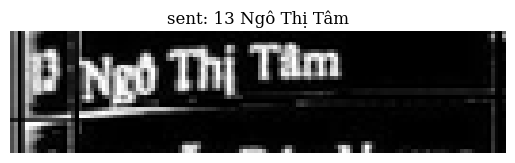

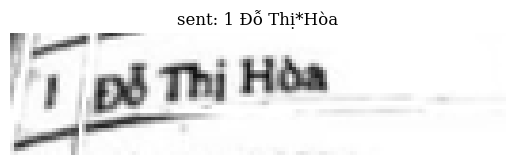

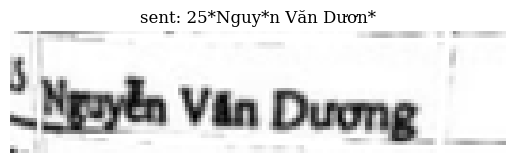

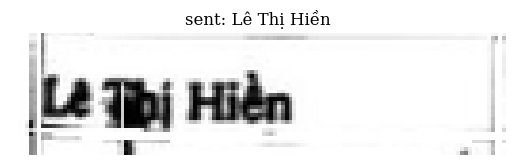

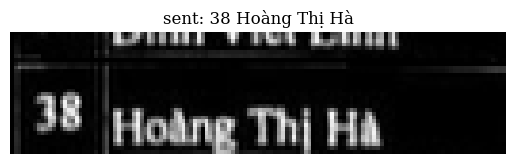

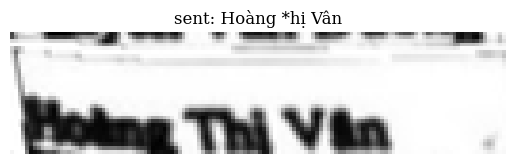

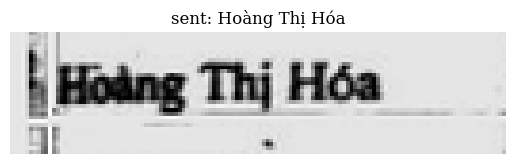

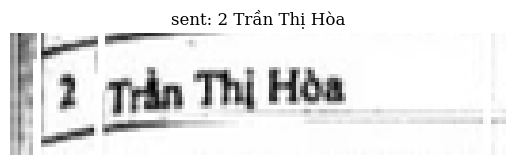

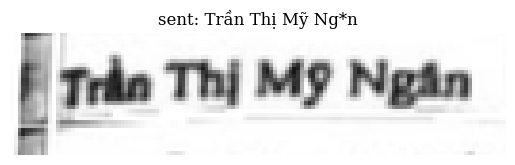

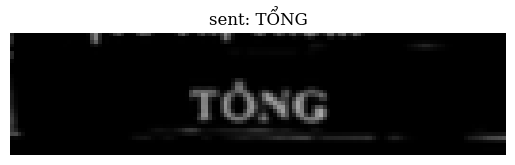

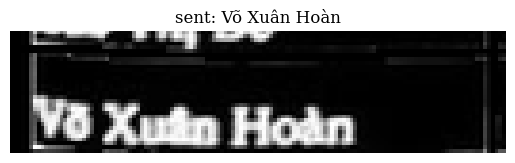

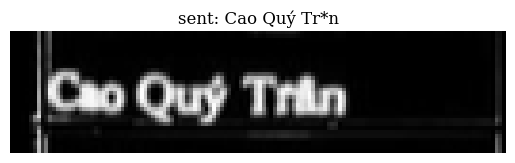

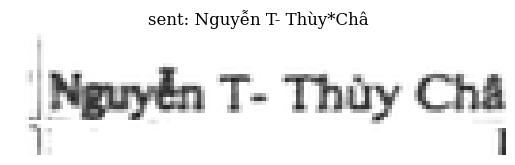

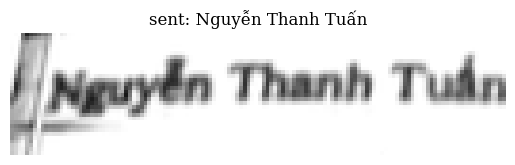

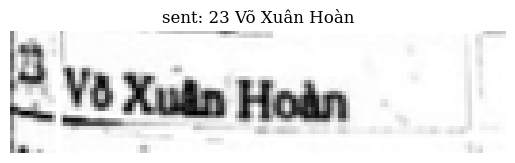

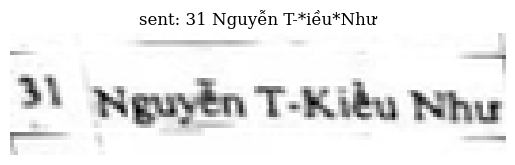

In [ ]:
trainer.visualize_dataset()

In [ ]:
trainer.train()

Visualize prediction from our trained model


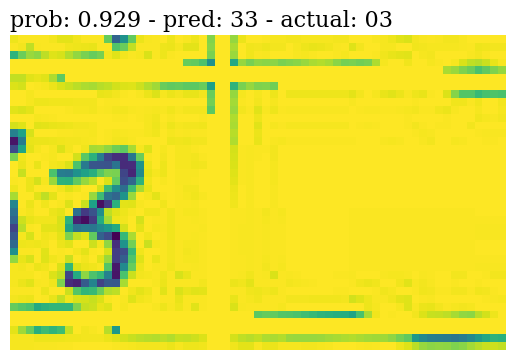

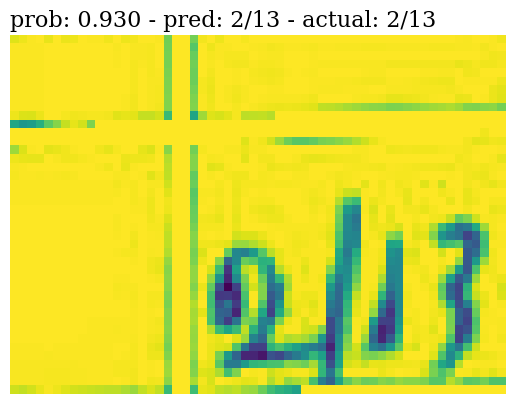

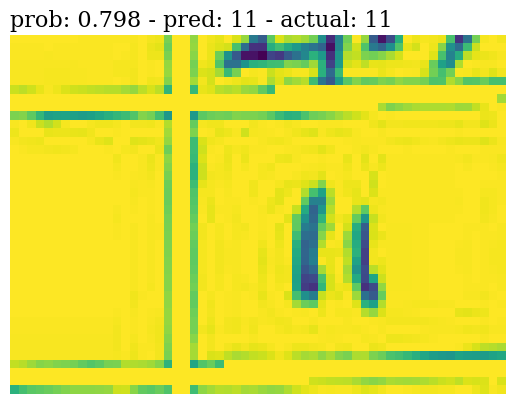

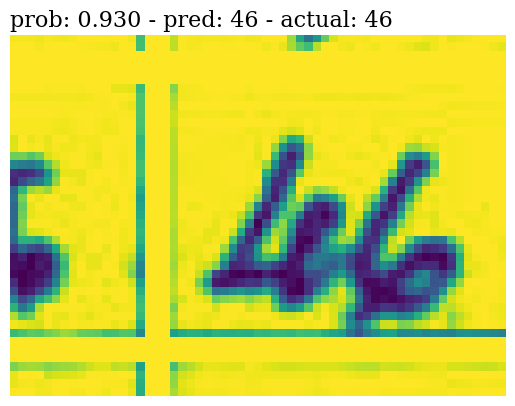

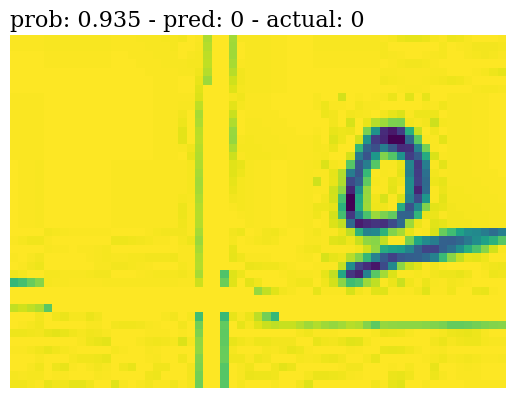

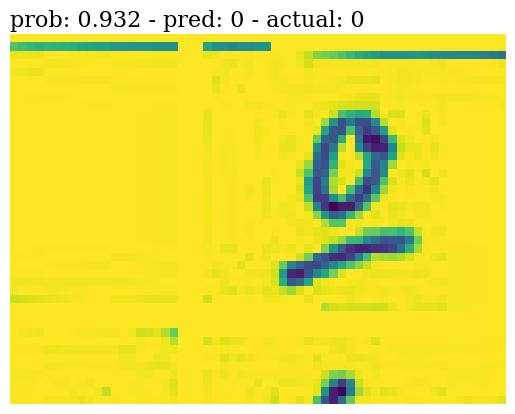

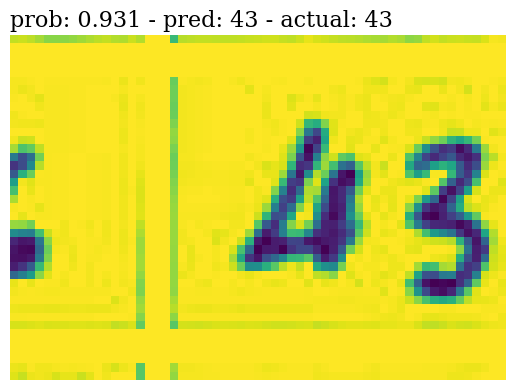

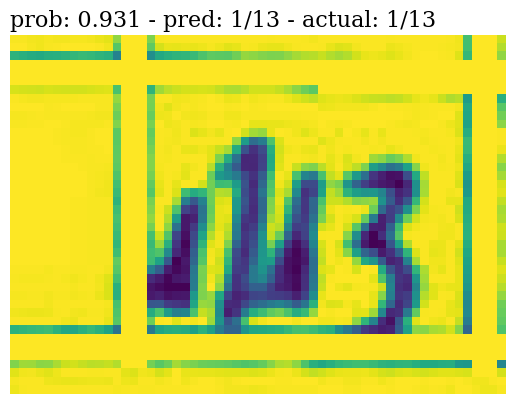

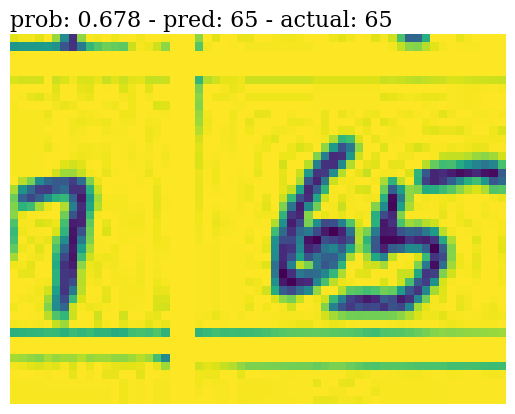

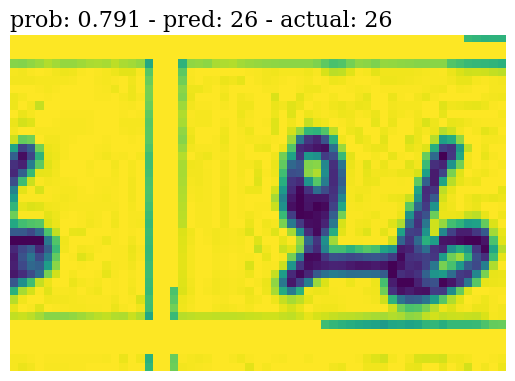

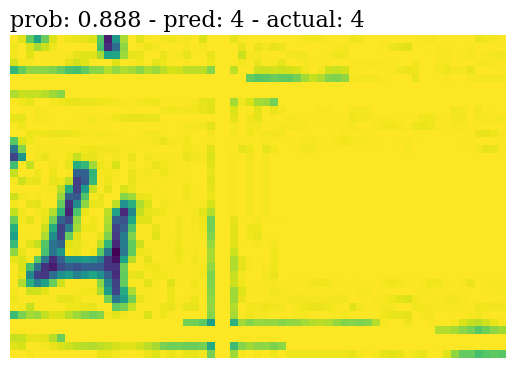

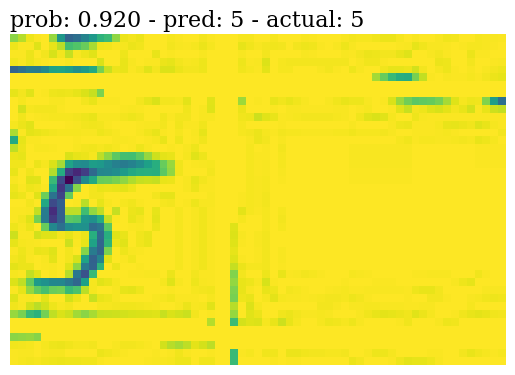

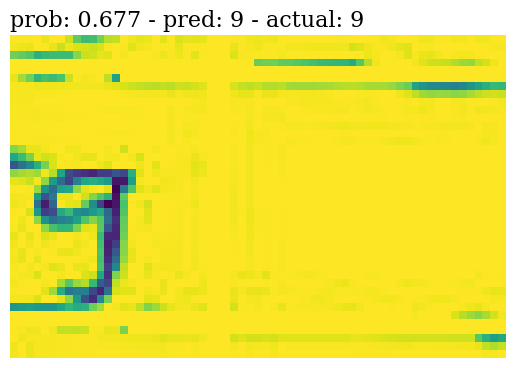

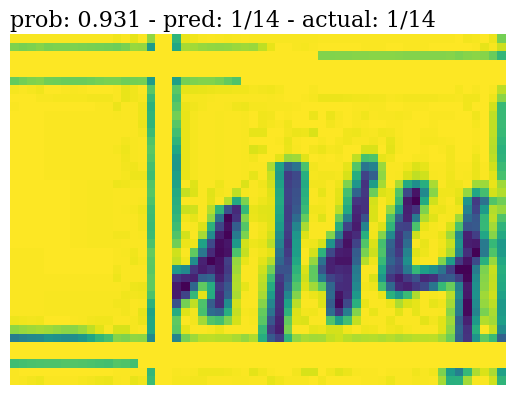

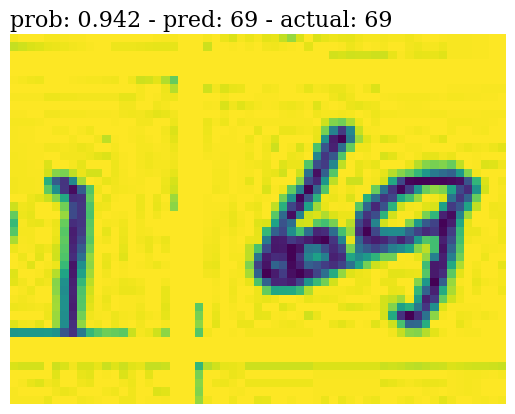

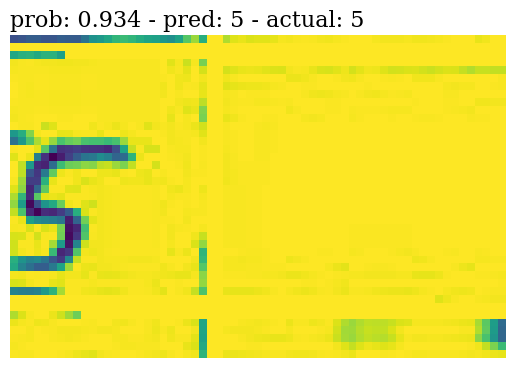

In [ ]:
trainer.visualize_prediction()

In [ ]:
trainer.config.save('config.yml')

Compute full seq accuracy for full valid dataset

In [ ]:
trainer.precision()

(0.9375, 0.96875)